
# **Лабораторна робота №3**
##### Варіант №8

### **Тема:** Розв’язування систем нелінійних рівнянь

**Мета:** ознайомлення студентів з чисельними методами розв’язування нелінійних
систем; набуття практичних навичок розв’язання таких задач (у тому числі - з
використанням комп’ютера).

Виконали:
1. Михайлюк Віталій
2. Лісовий Максим
3. Андрусик Вікторія
4. Оленич Максим

Лідер команди: **Михайлюк Віталій**

#### **Завдання**

1. Опрацювати теоретичний матеріал
2. Знайти наближений розв’язок заданої нелінійної системи з точністю до
10<sup>-3</sup>

- Методом Ньютона;
- Методом простої ітерації;
- Методом Зейделя.

**Надана система нелінійних рівнянь**

$$
\begin{cases}
\cos(2x - 1) + y = 0,8 \\
x - \cos y = 2
\end{cases}
$$


### **Програмна реалізація**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Callable, List, Tuple
import math 

In [2]:
def phi(vars: List[float]) -> List[float]:
    x, y = vars
    # Перетворення рівнянь
    # 1) x - cos(y) = 2          =>  x = 2 + cos(y)
    # 2) cos(2x - 1) + y = 0.8   =>  y = 0.8 - cos(2x - 1)
    
    new_x = 2.0 + math.cos(y)
    new_y = 0.8 - math.cos(2.0 * x - 1.0)
    
    return [new_x, new_y]

def phi_1(x: float, y: float) -> float:
    return 2.0 + math.cos(y)

def phi_2(x: float, y: float) -> float:
    return 0.8 - math.cos(2.0 * x - 1.0)

def system_equations(x: np.ndarray) -> np.ndarray:
    return np.array([
        np.cos(2.0 * x[0] - 1.0) + x[1] - 0.8,
        x[0] - np.cos(x[1]) - 2.0
    ])


def system_jacobian(x: np.ndarray) -> np.ndarray:
    return np.array([
        [-2.0 * np.sin(2.0 * x[0] - 1.0), 1.0],
        [1.0, np.sin(x[1])]
    ])

q = 0.85


**Метод Ньютона (Андрусик Вікторія)**

In [3]:
def newton_system(
        func: Callable[[np.ndarray], np.ndarray],
        jacobian: Callable[[np.ndarray], np.ndarray],
        x0: np.ndarray,
        tol: float = 1e-6,
        max_iter: int = 100
) -> Tuple[np.ndarray, int]:
    """
    Метод Ньютона для розв'язання системи нелінійних рівнянь.

    Алгоритм ітеративно знаходить вектор x, для якого F(x) = 0, використовуючи
    формулу x_{k+1} = x_k - J(x_k)^{-1} * F(x_k). Для обчислювальної стабільності
    замість обернення матриці розв'язується СЛАР: J(x_k) * dx = -F(x_k),
    після чого вектор наближень оновлюється: x_{k+1} = x_k + dx.
    """
    x = np.array(x0, dtype=float)

    for i in range(max_iter):
        f_val = func(x)

        # Перевірка умови збіжності за нев'язкою
        if np.linalg.norm(f_val, ord=np.inf) < tol:
            return x, i

        # Обчислення матриці Якобі та приросту dx
        J = jacobian(x)
        dx = np.linalg.solve(J, -f_val)
        x = x + dx

        # Перевірка умови збіжності за приростом аргументу
        if np.linalg.norm(dx, ord=np.inf) < tol:
            return x, i + 1

    raise ValueError("Метод Ньютона не зійшовся за задану кількість ітерацій")

**Метод Зейделя (Лісовий Максим)**

In [4]:
def seidel_nonlinear(
    phi1: Callable[[float, float], float],
    phi2: Callable[[float, float], float],
    x0: float,
    y0: float,
    q: float,
    epsilon: float = 1e-3,
    max_iter: int = 1000
) -> Tuple[float, float, List[float]]:
    """Розв'язує систему нелінійних рівнянь методом Зейделя з критерієм зупинки через q."""
    # Валідація вхідних параметрів
    if not (0.0 < q < 1.0):
        raise ValueError(f"Коефіцієнт стиску q має належати інтервалу (0, 1). Отримано: {q}")
    if epsilon <= 0:
        raise ValueError(f"Точність epsilon має бути додатною. Отримано: {epsilon}")
    if max_iter <= 0:
        raise ValueError(f"Кількість ітерацій max_iter має бути більшою за нуль. Отримано: {max_iter}")

    x_curr, y_curr = float(x0), float(y0)
    errors: List[float] = []

    stop_threshold = epsilon if q <= 0.5 else ((1.0 - q) / q) * epsilon

    for _ in range(max_iter):
        x_prev, y_prev = x_curr, y_curr

        x_curr = phi1(x_prev, y_prev)
        y_curr = phi2(x_curr, y_prev)


        delta = max(abs(x_curr - x_prev), abs(y_curr - y_prev))
        errors.append(delta)

        if delta <= stop_threshold:
            return x_curr, y_curr, errors

    raise RuntimeError(f"Метод Зейделя не зійшовся за {max_iter} ітерацій.")


**Метод простої ітерації (Оленич Максим)**

In [5]:
def simple_iteration_system(
    phi: Callable[[List[float]], List[float]],
    x0: List[float],
    q: float,
    epsilon: float = 0.001,
    max_iter: int = 1000
) -> Tuple[List[float], int]:
    """
    Реалізує метод простої ітерації для розв'язання систем нелінійних рівнянь.
    
    Математична основа:
    Початкова система рівнянь F(x, y) = 0 перетворюється до еквівалентного 
    ітераційного вигляду x = Phi_1(x, y) та y = Phi_2(x, y).
    Процес зупиняється на основі оцінки похибки з використанням 
    коефіцієнта стиску q: ||x_new - x_prev|| <= epsilon * (1 - q) / q.
    
    :param phi: Функція, що реалізує ітераційне відображення Phi(x).
    :param x0: Початкове наближення (список).
    :param q: Коефіцієнт збіжності (константа, q < 1).
    :param epsilon: Задана точність.
    :param max_iter: Максимальна кількість ітерацій.
    :return: Кортеж (список знайдених коренів, кількість витрачених ітерацій).
    """
    
    # Валідація вхідних параметрів
    if epsilon <= 0:
        raise ValueError("Точність epsilon має бути строго більшою за нуль.")
    if max_iter <= 0:
        raise ValueError("Максимальна кількість ітерацій має бути додатнім цілим числом.")
    if not isinstance(x0, list) or len(x0) == 0:
        raise ValueError("Початкове наближення x0 має бути непорожнім списком.")
    if not (0 < q < 1):
        raise ValueError("Коефіцієнт q має бути в межах (0, 1) для гарантії збіжності.")
        
    x_prev = np.array(x0, dtype=float)
    
    for iteration in range(1, max_iter + 1):
        try:
            x_new = np.array(phi(x_prev.tolist()), dtype=float)
        except Exception as e:
            raise RuntimeError(f"Помилка обчислення функції Phi на ітерації {iteration}: {e}")
        
        # Перевірка умови зупинки з використанням q
        max_diff = np.linalg.norm(x_new - x_prev, ord=np.inf)
        
        if max_diff <= epsilon * (1.0 - q) / q:
            return x_new.tolist(), iteration
            
        x_prev = x_new.copy()
        
    raise RuntimeError(f"Метод не зійшовся за {max_iter} ітерацій.")

**Виведення методів**

In [6]:
if __name__ == "__main__":
    print("-------------------------------------------------------------")
    print("Завдання №1: Метод Ньютона")
    # Пошук першого розв'язку (1, 2)
    try: 
        initial_guess_1 = np.array([1.6, 1.6])
        solution_1, iterations_1 = newton_system(system_equations, system_jacobian, initial_guess_1)
        print(f"Знайдений корінь: {np.round(solution_1, 3)}")
        print(f"Кількість ітерацій: {iterations_1}")
        print(f"Перевірка (F(x) ≈ 0): {system_equations(solution_1)}")
    except Exception as e:
        print("Помилка:", e)
        
    print("-------------------------------------------------------------")
    print("Завдання №2: Метод простої ітерації")
    # Початкове наближення
    # x = 2 + cos(y) -> cos() дає від -1 до 1, тому x в районі 2.
    # y = 0.8 - cos(...) -> y в районі 1.
    initial_guess = [1.6, 1.6] 
    try:
        solution, iters = simple_iteration_system(phi, initial_guess, q=0.85, epsilon=0.001)
        print(f"Знайдений корінь: [{np.round(solution[0], 3)}, {np.round(solution[1], 3)}]")
        print(f"Кількість ітерацій: {iters}")
    except Exception as e:
        print("Помилка:", e)

    print("-------------------------------------------------------------")
    print("Завдання №3: Метод Зейделя")
    try:
        x_sol, y_sol, errors = seidel_nonlinear(phi_1, phi_2, x0=1.6, y0=1.6, q=0.85, epsilon=1e-3)
        print(f"Знайдений корінь: [{np.round(x_sol, 3)}, {np.round(y_sol, 3)}]")
        print(f"Кількість ітерацій: {len(errors)}")
    except Exception as e:
        print("Помилка:", e)

    print("-------------------------------------------------------------")



-------------------------------------------------------------
Завдання №1: Метод Ньютона
Знайдений корінь: [1.859 1.712]
Кількість ітерацій: 4
Перевірка (F(x) ≈ 0): [ 5.20739007e-12 -1.81410442e-13]
-------------------------------------------------------------
Завдання №2: Метод простої ітерації
Знайдений корінь: [1.859, 1.712]
Кількість ітерацій: 68
-------------------------------------------------------------
Завдання №3: Метод Зейделя
Знайдений корінь: [1.859, 1.712]
Кількість ітерацій: 35
-------------------------------------------------------------


**Візуалізація**

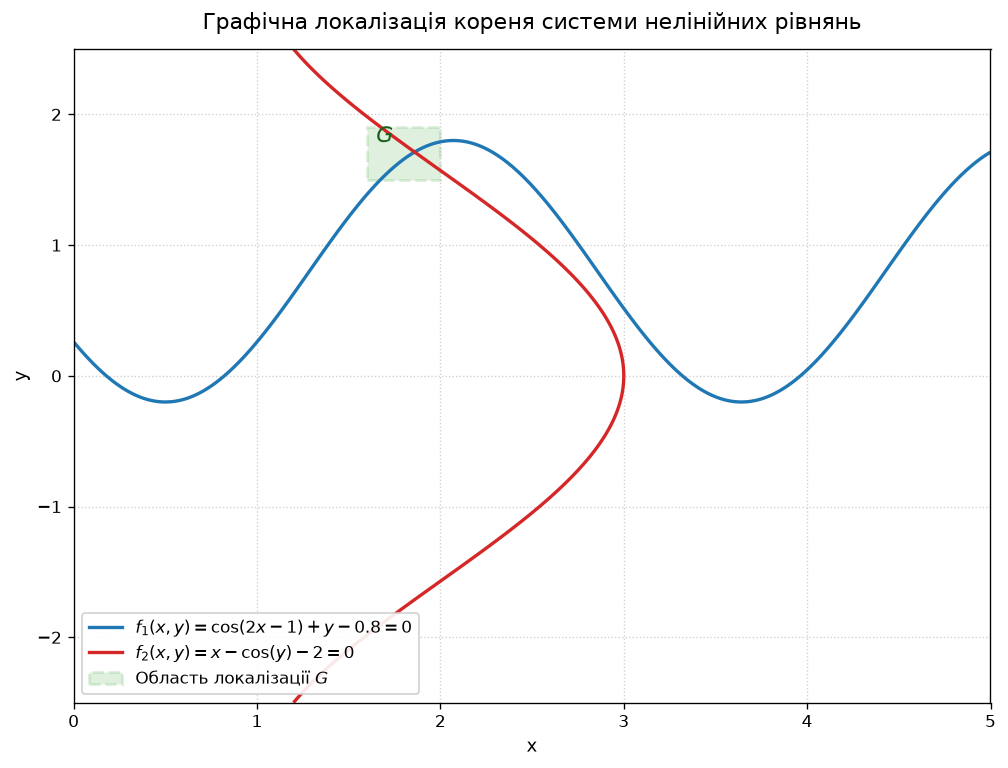

In [ ]:
def f1(x, y):
    return np.cos(2.0 * x - 1.0) + y - 0.8

def f2(x, y):
    return x - np.cos(y) - 2.0

x_vals = np.linspace(0, 5, 500)
y_vals = np.linspace(-2.5, 2.5, 500)
X, Y = np.meshgrid(x_vals, y_vals)

Z1 = f1(X, Y)
Z2 = f2(X, Y)

rect_x = [1.6, 2]
rect_y = [1.5, 1.9]

plt.figure(figsize=(8.5, 6.5), dpi=120)

plt.contour(X, Y, Z1, levels=[0], colors='#1f77b4', linewidths=2.0)
plt.contour(X, Y, Z2, levels=[0], colors='#d62728', linewidths=2.0)

plt.plot([], [], color='#1f77b4', lw=2.0, label=r'$f_1(x, y) = \cos(2x - 1) + y - 0.8 = 0$')
plt.plot([], [], color='#d62728', lw=2.0, label=r'$f_2(x, y) = x - \cos(y) - 2 = 0$')

rect = patches.Rectangle(
    (rect_x[0], rect_y[0]), 
    rect_x[1] - rect_x[0],
    rect_y[1] - rect_y[0],
    linewidth=1.8,
    edgecolor='#2ca02c',
    facecolor='#2ca02c',
    alpha=0.15,
    linestyle='--',
    label=r'Область локалізації $G$'
)
plt.gca().add_patch(rect)

plt.text(rect_x[0] + 0.05, rect_y[1] - 0.12, r'$G$', fontsize=13, fontweight='bold', color='#1b611b')

plt.title("Графічна локалізація кореня системи нелінійних рівнянь", fontsize=13, pad=12)
plt.xlabel("x", fontsize=11)
plt.ylabel("y", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()

#### **Висновки**



У ході виконання лабораторної роботи було досліджено та реалізовано чисельні методи розв'язання системи нелінійних рівнянь: метод Ньютона, метод простої ітерації (МПІ) та метод Зейделя.

На підготовчому етапі виконано аналітичне та графічне дослідження системи. На основі обмеженості тригонометричних функцій вихідних рівнянь було теоретично визначено глобальну область існування розв'язків та побудовано лінії рівня $f_1(x, y) = 0$ і $f_2(x, y) = 0$. У результаті виявлено та локалізовано єдиний ізольований корінь системи в замкненій області $G = [1.6, 2] \times [1.5, 1.9]$.

Для забезпечення збіжності ітераційних процесів МПІ та методу Зейделя систему зведено до еквівалентного вигляду зі стискаючим відображенням $X = \Phi(X)$. Аналітично розраховано матрицю Якобі $J_\Phi(x, y)$ та оцінено її нескінченну норму в області $G$, що підтвердило виконання достатньої умови теореми Банаха про нерухому точку ($q = \max_{(x,y)\in G} \Vert{}J_\Phi\Vert{}_\infty < 1$). Це дало змогу коректно застосувати апостеріорний критерій зупинки ітераційного процесу $\Vert{}x_{k+1} - x_k\Vert{} \le \frac{1-q}{q} \varepsilon$.

Порівняльний аналіз чисельних методів продемонстрував такі закономірності:

1. **Метод Ньютона** показав найвищу швидкість збіжності (квадратичну), досягнувши заданої точності $\varepsilon = 10^{-3}$ лише за 4 ітерації з мінімальною фінальною нев'язкою $\Vert{}F(X^*)\Vert{}_\infty \approx 10^{-7}$. Попри необхідність обчислення матриці Якобі та розв'язання СЛАР для приростів $dx$ на кожному кроці, метод є найбільш ефективним за загальною кількістю ітерацій.
2. **Метод Зейделя** продемонстрував відчутне прискорення лінійної збіжності порівняно з МПІ завдяки негайному використанню оновленого значення $x_{k+1}$ для розрахунку $y_{k+1}$, що зменшило загальну кількість ітерацій до досягнення критерію зупинки.
3. **Метод простої ітерації (МПІ)** показав стабільну, але монотонну лінійну збіжність, потребуючи найбільшої кількості ітерацій серед усіх трьох підходів, що зумовлено близькістю коефіцієнта стиску $q$ до одиниці.

Усі три методи зійшлися до одного й того самого вектора розв'язку $X^* \approx (1.859, \; 1.712)$, що разом із перевіркою прямої нев'язки $F(X^*) \approx 0$ підтверджує математичну коректність реалізації розроблених алгоритмів.